### Selecting SVI variables

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt


from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve
import geopandas as gpd

# these libraries are not dependencies of pymc
import networkx as nx
import nutpie
import libpysal as ps

In [2]:
RANDOM_SEED = 8926
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
current_path = os.getcwd()

In [4]:
save_path = "/Users/h6x/CODE/Archive/git/spatial-risk-tda/plots/disease_modeling_multi_variable/tn/variable_selection"

In [5]:
state_abb = "TN"
state_abb_lower = state_abb.lower()

Load the data

In [6]:
# SVI
svi_tda_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"tda_summaries_2018_{state_abb}_down.csv"), dtype={'STCNTY': str})

# SMR
smr_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"smr_data_2018_{state_abb}.csv"), dtype={'FIPS': str})

# GEO: get geometry data
geo_data = gpd.read_file(os.path.join(current_path, "data", "raw_data", "SVI2018_US_county.gdb"), dtype={"FIPS": str})

geo_data = geo_data[['FIPS', 'geometry','ST_ABBR']]

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


In [7]:
# combine smr on FIPS and svi data on STCNTY - left
combined_data = pd.merge(smr_data, svi_tda_data, left_on="FIPS", right_on="STCNTY", how="left")

# merge combined data with geo data
combined_data = pd.merge(combined_data, geo_data, on="FIPS", how="left")

In [8]:
# print the shape
print(f"Shape of the combined data: {combined_data.shape}")

Shape of the combined data: (95, 89)


In [9]:
# get the 'state' data

combined_data = combined_data[combined_data['ST_ABBR'] == state_abb]

In [10]:
combined_data.shape

(95, 89)

In [11]:
# Adding this just to plot original data!
# Replace 0 with NaN in observed_deaths column
combined_data_map = combined_data.copy()
combined_data_map["observed_deaths"] = combined_data_map["observed_deaths"].replace(0.0, np.nan)

gdf_map = gpd.GeoDataFrame(combined_data_map, geometry='geometry')

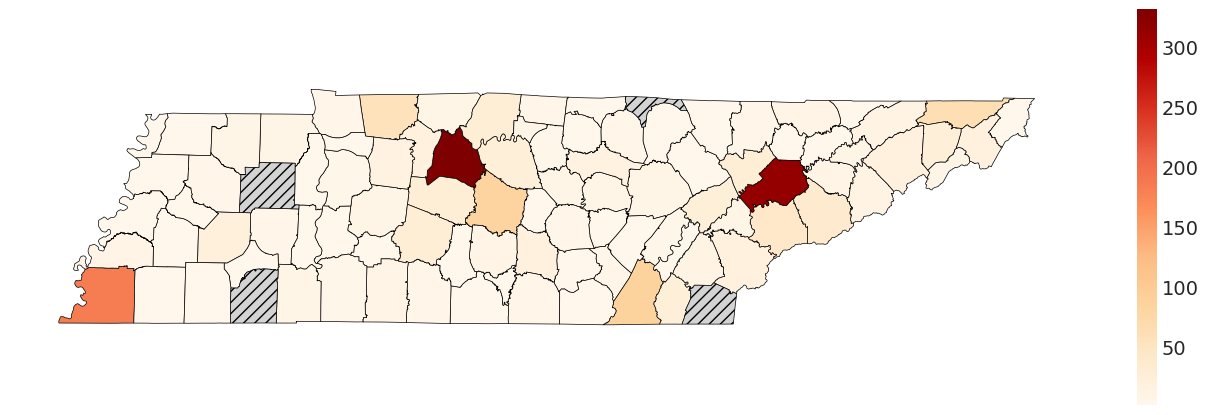

In [12]:
import matplotlib.pyplot as plt
import geopandas as gpd

# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf_map.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"observed_deaths.png"), bbox_inches='tight', dpi=300)

Cleaning the data: Removing the rows with missing observed deaths, islands, few states

In [13]:
# filter by column to have columns start with EP_ or SMR and geometry and FIPS and observed_death and expected_death
combined_data = combined_data.filter(regex='EP_|SMR|geometry|FIPS|observed_death|expected_death')

# drop the rows with observed_death = 0
combined_data = combined_data[combined_data['observed_deaths'] > 0]

# make it a geodataframe
gdf = gpd.GeoDataFrame(combined_data, geometry='geometry')

# Compute Queen adjacency
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# if we keep the islands it will cause error in the adjacency computation(empty adjacencies)
# Get the islands fips to a list
islands = w.islands

# drop the islands
combined_data = combined_data[~combined_data["FIPS"].isin(islands)]

# drop rows with FIPS starts with 72, 78, 02, 15, 60
combined_data = combined_data[~combined_data['FIPS'].str.startswith(('72', '78', '02', '15', '60'))]

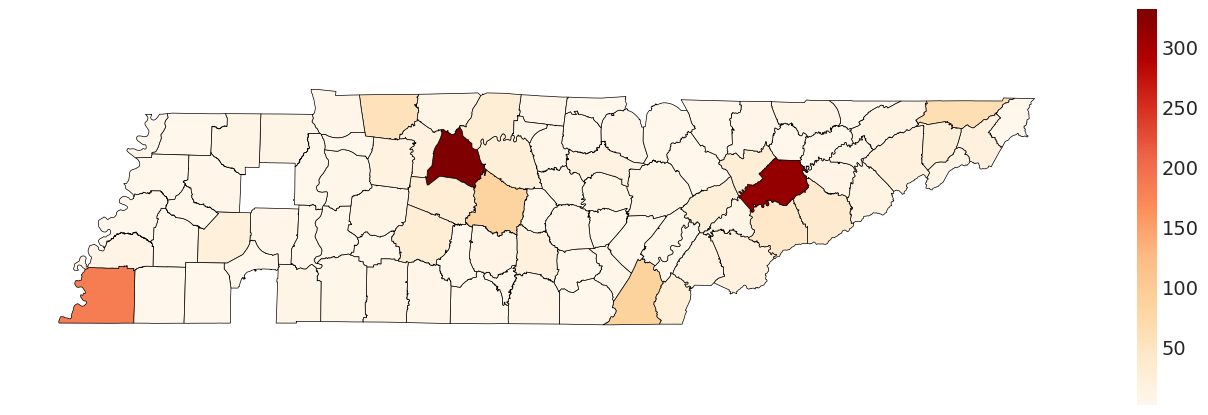

In [14]:
# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.show()

Combine TDA summaries for each state(all variables)

In [15]:
# get the column names with _AL
al_cols = combined_data.filter(regex='_AL').columns

print(f"Columns with _AL: {al_cols}")

# sum the columns with _AL
combined_data['AL'] = combined_data[al_cols].sum(axis=1)

# drop the columns with _AL
# combined_data.drop(columns=al_cols, inplace=True)

# get the column names with _TL

tl_cols = combined_data.filter(regex='_TL').columns

print(f"Columns with _TL: {tl_cols}")

# sum the columns with _TL
combined_data['TL'] = combined_data[tl_cols].sum(axis=1)

# drop the columns with _TL
# combined_data.drop(columns=tl_cols, inplace=True)

# get the column names with _AML
aml_cols = combined_data.filter(regex='_AML').columns

print(f"Columns with _AML: {aml_cols}")

# sum the columns with _AML
combined_data['AML'] = combined_data[aml_cols].sum(axis=1)

# drop the columns with _AML
# combined_data.drop(columns=aml_cols, inplace=True)

# get the column names with _TML
tml_cols = combined_data.filter(regex='_TML').columns

print(f"Columns with _TML: {tml_cols}")

# sum the columns with _TML
combined_data['TML'] = combined_data[tml_cols].sum(axis=1)

# drop the columns with _TML
# combined_data.drop(columns=tml_cols, inplace=True)

Columns with _AL: Index(['EP_POV_AL', 'EP_UNEMP_AL', 'EP_PCI_AL', 'EP_NOHSDP_AL',
       'EP_UNINSUR_AL', 'EP_AGE65_AL', 'EP_AGE17_AL', 'EP_DISABL_AL',
       'EP_SNGPNT_AL', 'EP_LIMENG_AL', 'EP_MINRTY_AL', 'EP_MUNIT_AL',
       'EP_MOBILE_AL', 'EP_CROWD_AL', 'EP_NOVEH_AL', 'EP_GROUPQ_AL'],
      dtype='object')
Columns with _TL: Index(['EP_POV_TL', 'EP_UNEMP_TL', 'EP_PCI_TL', 'EP_NOHSDP_TL',
       'EP_UNINSUR_TL', 'EP_AGE65_TL', 'EP_AGE17_TL', 'EP_DISABL_TL',
       'EP_SNGPNT_TL', 'EP_LIMENG_TL', 'EP_MINRTY_TL', 'EP_MUNIT_TL',
       'EP_MOBILE_TL', 'EP_CROWD_TL', 'EP_NOVEH_TL', 'EP_GROUPQ_TL'],
      dtype='object')
Columns with _AML: Index(['EP_POV_AML', 'EP_UNEMP_AML', 'EP_PCI_AML', 'EP_NOHSDP_AML',
       'EP_UNINSUR_AML', 'EP_AGE65_AML', 'EP_AGE17_AML', 'EP_DISABL_AML',
       'EP_SNGPNT_AML', 'EP_LIMENG_AML', 'EP_MINRTY_AML', 'EP_MUNIT_AML',
       'EP_MOBILE_AML', 'EP_CROWD_AML', 'EP_NOVEH_AML', 'EP_GROUPQ_AML'],
      dtype='object')
Columns with _TML: Index(['EP_POV_TML', '

Get the adjacency matrix

In [16]:
# create the queen adjacency matrix
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# Spatial adjacency matrix (N x N) with binary entries for neighbor relationships.
# make it into a matrix
W = w.full()[0]

In [17]:
# print the shape of W
print(f"Shape of W: {W.shape}")

Shape of W: (91, 91)


Variable selection

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [19]:
combined_data = combined_data.rename(columns={
    "EP_POV_AV_ORI": "Poverty",
    "EP_UNEMP_AV_ORI": "Unemployment",
    "EP_PCI_AV_ORI": "Per capita income",
    "EP_NOHSDP_AV_ORI": "No high school diploma",
    "EP_AGE65_AV_ORI": "Population aged 65+",
    "EP_AGE17_AV_ORI": "Population aged ≤17",
    "EP_DISABL_AV_ORI": "Disability",
    "EP_SNGPNT_AV_ORI": "Single-parent households",
    "EP_MINRTY_AV_ORI": "Minority population",
    "EP_LIMENG_AV_ORI": "Limited English proficiency",
    "EP_MUNIT_AV_ORI": "Multi-unit housing",
    "EP_MOBILE_AV_ORI": "Mobile homes",
    "EP_CROWD_AV_ORI": "Household crowding",
    "EP_NOVEH_AV_ORI": "No vehicle access",
    "EP_GROUPQ_AV_ORI": "Group quarters population",
})

In [20]:
candidate_cols = [
    "Poverty",
    "Unemployment",
    "Per capita income",
    "No high school diploma",
    "Population aged 65+",
    "Population aged ≤17",
    "Disability",
    "Single-parent households",
    "Minority population",
    "Limited English proficiency",
    "Multi-unit housing",
    "Mobile homes",
    "Household crowding",
    "No vehicle access",
    "Group quarters population"
]

In [21]:
# Create a subset df (Drop NaNs, as VIF cannot handle them)
X_subset = combined_data[candidate_cols].dropna()

In [22]:
X_subset.shape

(91, 15)

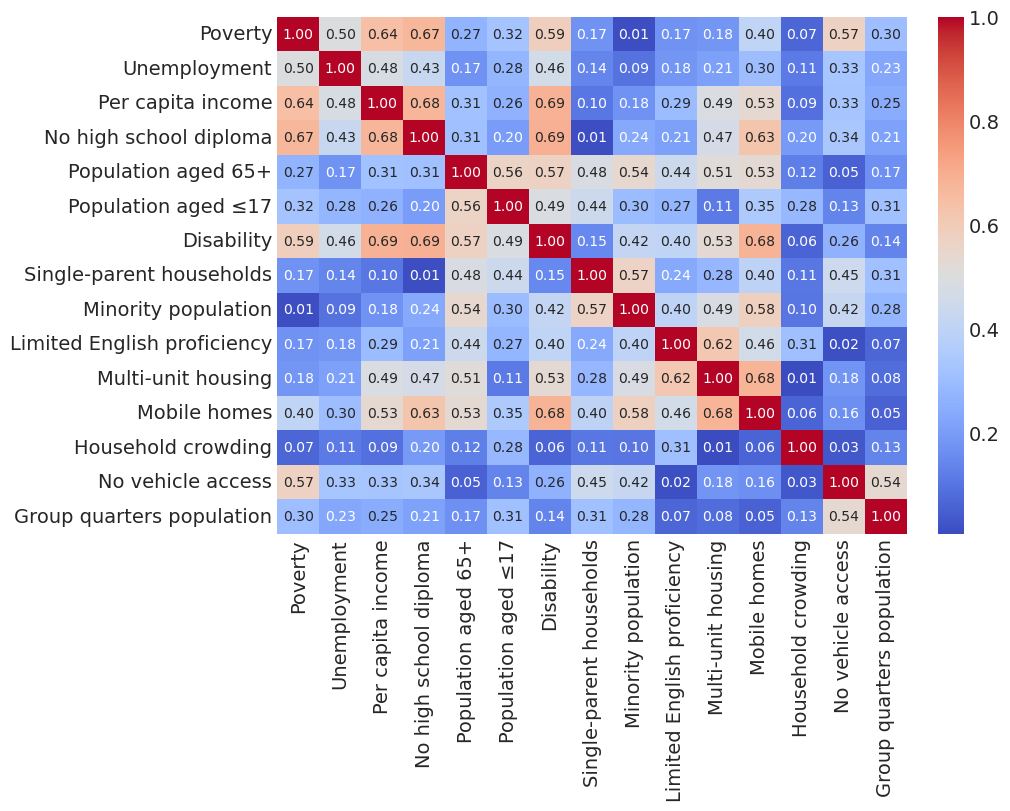

In [23]:
# Calculate correlation matrix
corr_matrix = X_subset.corr().abs()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title("Correlation Matrix")
# plt.show()
plt.savefig(os.path.join( save_path, f"correlation_matrix_all_variables{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

In [24]:
# drop one of the variables from each pair with correlation > 0.7
to_drop = set()
threshold = 0.7
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)


print(f"Columns to drop due to high correlation: {to_drop}")

Columns to drop due to high correlation: set()


In [25]:
# from candidate_cols drop the columns in to_drop except 'EP_DISABL_AV_ORI'
# we want to keep 'Disability' even if it is in to_drop because of domain knowledge

candidate_cols = [col for col in candidate_cols if col not in to_drop or col == 'Disability']
print(f"Final candidate columns after dropping: {candidate_cols}")

Final candidate columns after dropping: ['Poverty', 'Unemployment', 'Per capita income', 'No high school diploma', 'Population aged 65+', 'Population aged ≤17', 'Disability', 'Single-parent households', 'Minority population', 'Limited English proficiency', 'Multi-unit housing', 'Mobile homes', 'Household crowding', 'No vehicle access', 'Group quarters population']


In [26]:
# Create a subset df with the final candidate columns
X_subset = combined_data[candidate_cols]

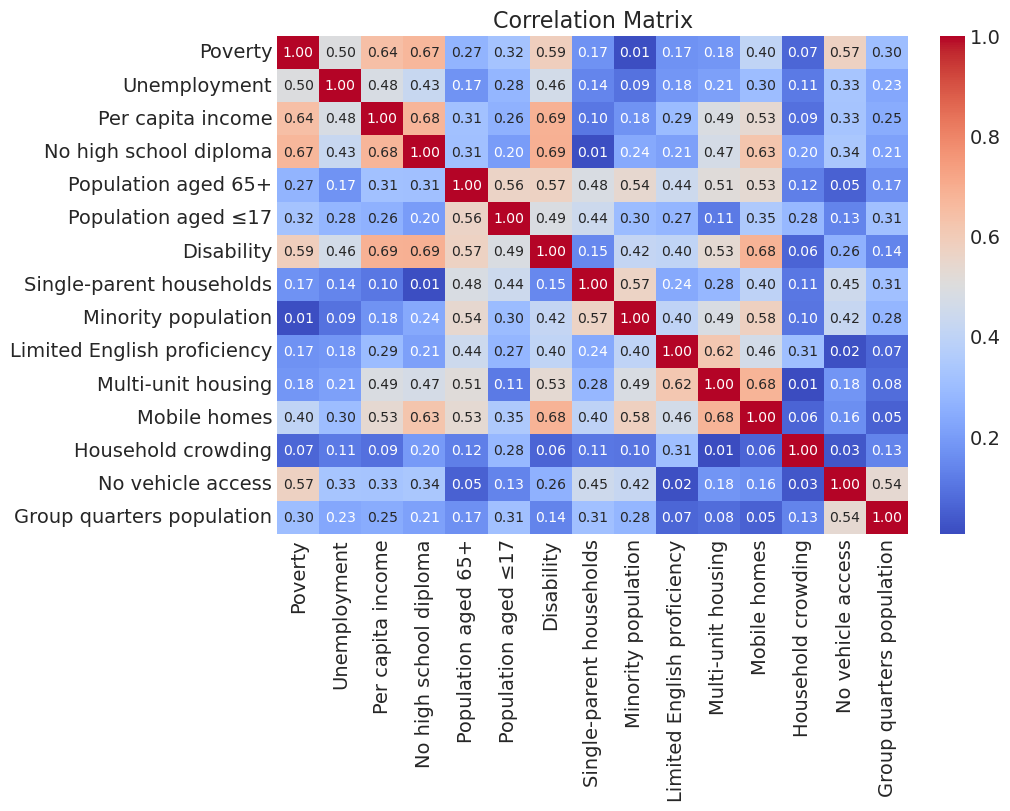

In [27]:
# Calculate correlation matrix
corr_matrix = X_subset.corr().abs()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Variance Inflation Factor - VIF

In [28]:
def calc_vif(X):
    # VIF dataframe
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    
    # Calculate VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(len(X.columns))]
    
    return vif_data.sort_values(by="VIF", ascending=False)

# Run it
print(calc_vif(X_subset))

                        feature         VIF
5           Population aged ≤17  129.122753
6                    Disability   98.568534
4           Population aged 65+   66.927278
3        No high school diploma   64.816005
0                       Poverty   60.698730
2             Per capita income   54.924140
7      Single-parent households   41.473590
13            No vehicle access   29.128772
11                 Mobile homes   25.217175
1                  Unemployment   21.668205
12           Household crowding   11.246281
8           Minority population    6.271152
10           Multi-unit housing    5.938743
9   Limited English proficiency    4.015411
14    Group quarters population    2.938901


In [29]:
def auto_select_variables(X, threshold=10.0):
    """
    Iteratively drops the variable with the highest VIF until 
    all remaining variables are below the threshold.
    """
    X_optim = X.copy()
    dropped_cols = []
    
    while True:
        vif_data = calc_vif(X_optim)
        max_vif = vif_data['VIF'].max()
        
        # If the worst offender is above threshold, drop it
        if max_vif > threshold:
            feature_to_drop = vif_data.sort_values('VIF', ascending=False)['feature'].iloc[0]
            print(f"Dropping '{feature_to_drop}' with VIF: {max_vif:.2f}")
            X_optim = X_optim.drop(columns=[feature_to_drop])
            dropped_cols.append(feature_to_drop)
        else:
            break

    print(f"\nOptimization Complete. \nDropped: {dropped_cols}")
    print(f"Remaining: {list(X_optim.columns)}")
    return X_optim

# Run the automated selection
final_X = auto_select_variables(X_subset, threshold=10.0) # Use 10.0 for looser, 5.0 for stricter

# print the final columns
print(f"Final columns after VIF selection: {final_X.columns.tolist()}")

Dropping 'Population aged ≤17' with VIF: 129.12
Dropping 'Disability' with VIF: 98.45
Dropping 'Poverty' with VIF: 60.64
Dropping 'No high school diploma' with VIF: 51.59
Dropping 'Population aged 65+' with VIF: 47.54
Dropping 'Single-parent households' with VIF: 22.17
Dropping 'Unemployment' with VIF: 17.24
Dropping 'Per capita income' with VIF: 12.36
Dropping 'No vehicle access' with VIF: 11.76

Optimization Complete. 
Dropped: ['Population aged ≤17', 'Disability', 'Poverty', 'No high school diploma', 'Population aged 65+', 'Single-parent households', 'Unemployment', 'Per capita income', 'No vehicle access']
Remaining: ['Minority population', 'Limited English proficiency', 'Multi-unit housing', 'Mobile homes', 'Household crowding', 'Group quarters population']
Final columns after VIF selection: ['Minority population', 'Limited English proficiency', 'Multi-unit housing', 'Mobile homes', 'Household crowding', 'Group quarters population']


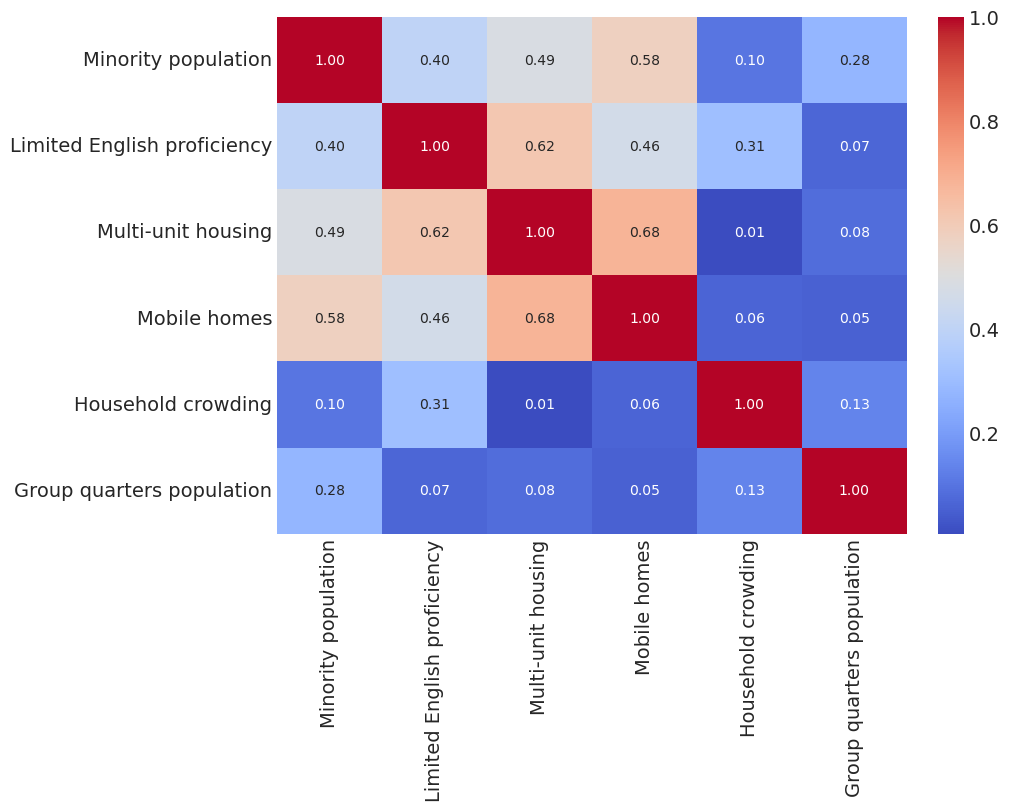

In [30]:
# Calculate correlation matrix
corr_matrix = final_X.corr().abs()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title("Correlation Matrix")
# plt.show()
plt.savefig(os.path.join( save_path, f"correlation_matrix_selected_variables{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

In [31]:
combined_data['Total average lifespan'] = combined_data['EP_UNEMP_AL'] + combined_data['EP_AGE65_AL'] + combined_data['EP_MINRTY_AL']+ combined_data['EP_LIMENG_AL']+ combined_data['EP_MUNIT_AL']+ combined_data['EP_CROWD_AL']+ combined_data['EP_GROUPQ_AL']

# mean center and standerdize Total average lifespan
combined_data['Total average lifespan'] = (combined_data['Total average lifespan'] - combined_data['Total average lifespan'].mean()) / combined_data['Total average lifespan'].std()

# print the SD of Total average lifespan
print(f"SD of Total average lifespan: {combined_data['Total average lifespan'].std()}")



SD of Total average lifespan: 1.0


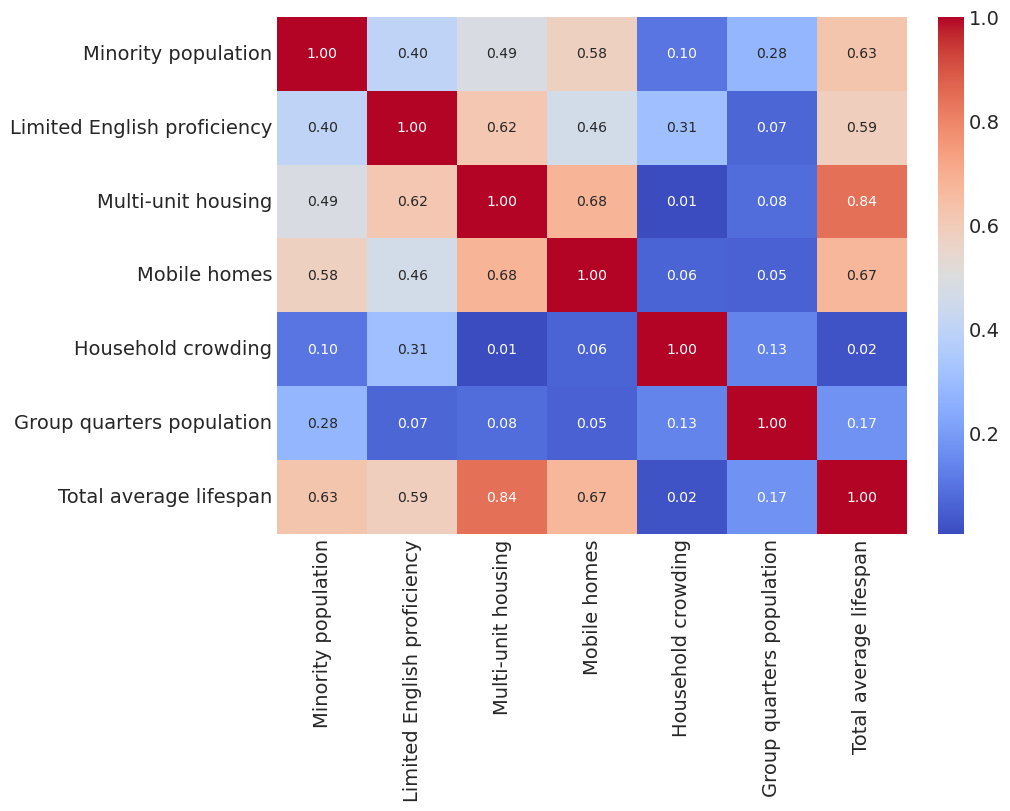

In [32]:
# plot correlation matrix of the final selected variables including 'AL'
final_cols = final_X.columns.tolist() + ['Total average lifespan']
corr_matrix = combined_data[final_cols].corr().abs()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title("Correlation Matrix")
plt.savefig(os.path.join( save_path, f"correlation_matrix_final_selected_variables_with_AL{state_abb_lower}.png"), bbox_inches='tight', dpi=300)